# Práctica 3. Autoencoder
### Redes Neuronales Artificiales y Aprendizaje Profundo
**José Luis Haro Díaz**

# Importar librerias necesarias

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

print('TensorFlow version:', tf.__version__)
%matplotlib inline

TensorFlow version: 2.19.0


# Cargar y procesar MNIST

In [18]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

#Normalizar píxeles
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

x_train_flat = x_train.reshape(-1, 784)
x_test_flat  = x_test.reshape(-1, 784)

print('Train shape:', x_train_flat.shape)
print('Test  shape:', x_test_flat.shape)

Train shape: (60000, 784)
Test  shape: (10000, 784)


# Agregar ruido gaussiano a los datos de entrenamiento

In [19]:
def add_noise(images, noise_factor=0.3):
    noisy = images + noise_factor * np.random.randn(*images.shape)
    return np.clip(noisy, 0.0, 1.0)

NOISE_FACTOR = 0.3

x_train_noisy = add_noise(x_train_flat, NOISE_FACTOR)
x_test_noisy  = add_noise(x_test_flat,  NOISE_FACTOR)

print('Train noisy shape:', x_train_noisy.shape)
print('Test  noisy shape:', x_test_noisy.shape)

Train noisy shape: (60000, 784)
Test  noisy shape: (10000, 784)


# Definición del Denoising Autoencoder

In [20]:
class Encoder(Model):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.dense1 = Dense(256, activation='relu')
        self.dense2 = Dense(128, activation='relu')
        self.latent = Dense(latent_dim, activation='relu')

    def call(self, x):
        x = self.dense1(x)
        x = self.dense2(x)
        return self.latent(x)


class Decoder(Model):
    def __init__(self):
        super(Decoder, self).__init__()
        self.dense1 = Dense(128, activation='relu')
        self.dense2 = Dense(256, activation='relu')
        self.out    = Dense(784, activation='sigmoid')

    def call(self, x):
        x = self.dense1(x)
        x = self.dense2(x)
        return self.out(x)


class DenoisingAutoencoder(Model):
    def __init__(self, latent_dim=64):
        super(DenoisingAutoencoder, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder()

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


LATENT_DIM = 64
model = DenoisingAutoencoder(latent_dim=LATENT_DIM)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=MeanSquaredError(),
    metrics=['accuracy', 'mse']   # igual que en clase
)

# Forward pass para inicializar pesos antes de summary
_ = model(x_train_noisy[:1])
model.summary()

Model: "denoising_autoencoder_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_2 (Encoder)             │ ?                      │       242,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_2 (Decoder)             │ ?                      │       242,832 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

# Entrenamiento

In [21]:
EPOCHS     = 30
BATCH_SIZE = 256

history = model.fit(
    x_train_noisy,
    x_train_flat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_flat),
    verbose=1
)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.0085 - loss: 0.0575 - mse: 0.0575 - val_accuracy: 0.0103 - val_loss: 0.0318 - val_mse: 0.0318
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.0114 - loss: 0.0269 - mse: 0.0269 - val_accuracy: 0.0113 - val_loss: 0.0231 - val_mse: 0.0231
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.0119 - loss: 0.0215 - mse: 0.0215 - val_accuracy: 0.0103 - val_loss: 0.0197 - val_mse: 0.0197
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.0111 - loss: 0.0189 - mse: 0.0189 - val_accuracy: 0.0102 - val_loss: 0.0176 - val_mse: 0.0176
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.0110 - loss: 0.0173 - mse: 0.0173 - val_accuracy: 0.0099 - val_loss: 0.0165 - val_mse: 0.0165
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.0112 - loss: 0.0161 - mse: 0.0161 - val_accuracy: 0.0137 - val_loss: 0.0158 - val_mse: 0.0158
Epoch 7/30
235/235 ━━━━━━━━━━━━

# Gráficas de entrenamiento

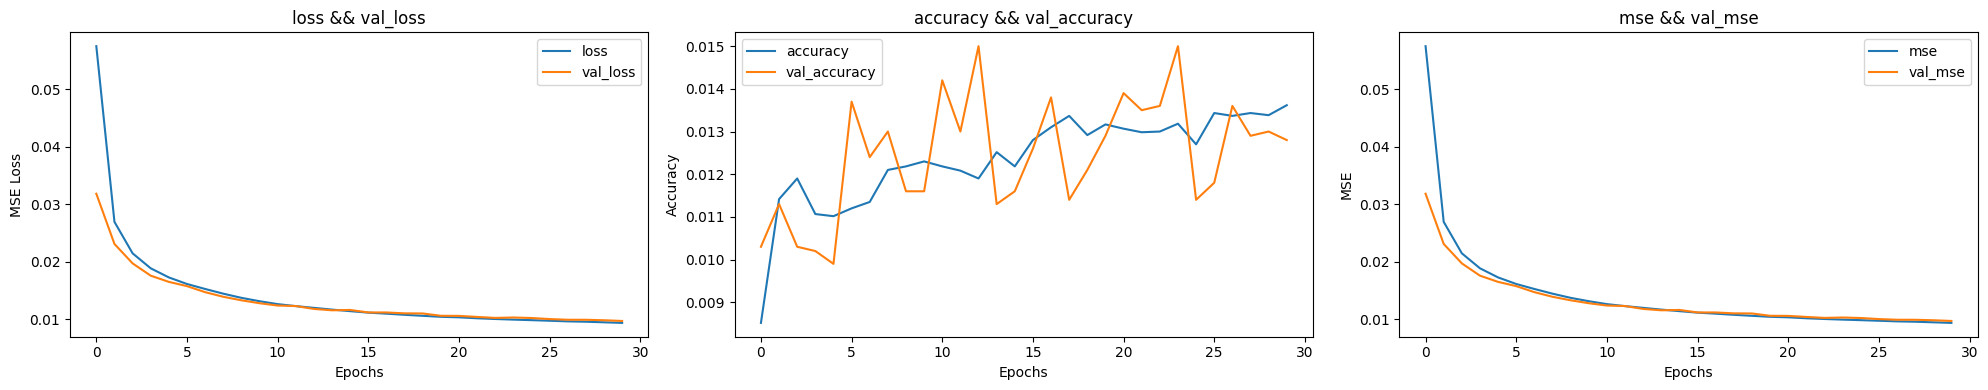

In [22]:
figure, ax = plt.subplots(1, 3, figsize=(20, 4))

ax[0].plot(history.history['loss'])
ax[0].plot(history.history['val_loss'])
ax[0].set_title('loss && val_loss')
ax[0].set_ylabel('MSE Loss')
ax[0].set_xlabel('Epochs')
ax[0].legend(['loss', 'val_loss'])

ax[1].plot(history.history['accuracy'])
ax[1].plot(history.history['val_accuracy'])
ax[1].set_title('accuracy && val_accuracy')
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].legend(['accuracy', 'val_accuracy'])

ax[2].plot(history.history['mse'])
ax[2].plot(history.history['val_mse'])
ax[2].set_title('mse && val_mse')
ax[2].set_ylabel('MSE')
ax[2].set_xlabel('Epochs')
ax[2].legend(['mse', 'val_mse'])

plt.tight_layout()
plt.show()

# Función `plot` – Original vs Reconstruida vs Error

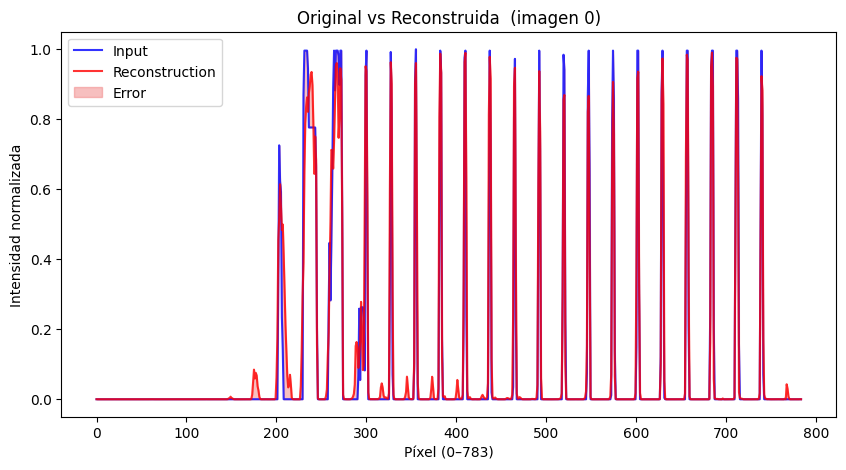

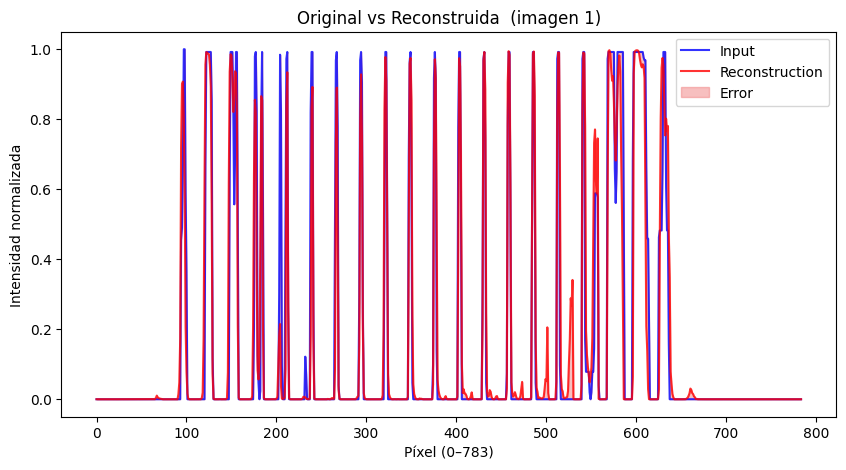

In [23]:
def plot(noisy_data, clean_data, n):
    enc_img = model.encoder(noisy_data)
    dec_img = model.decoder(enc_img).numpy()

    input_vec = noisy_data[n] #imagen con ruido (entrada)
    recon_vec = dec_img[n] #reconstrucción (salida)
    clean_vec = clean_data[n] #imagen original (referencia)

    plt.figure(figsize=(10, 5))
    plt.plot(clean_vec,  'b', alpha=0.8, label='Original (limpia)')
    plt.plot(recon_vec,  'r', alpha=0.8, label='Reconstruction')
    plt.fill_between(
        np.arange(len(clean_vec)),
        clean_vec, recon_vec,
        color='lightcoral', alpha=0.5, label='Error'
    )
    plt.legend(labels=['Input', 'Reconstruction', 'Error'])
    plt.title(f'Original vs Reconstruida  (imagen {n})')
    plt.xlabel('Píxel (0–783)')
    plt.ylabel('Intensidad normalizada')
    plt.show()


plot(x_test_noisy, x_test_flat, 0)
plot(x_test_noisy, x_test_flat, 1)

# Original → Con ruido → Reconstruida

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


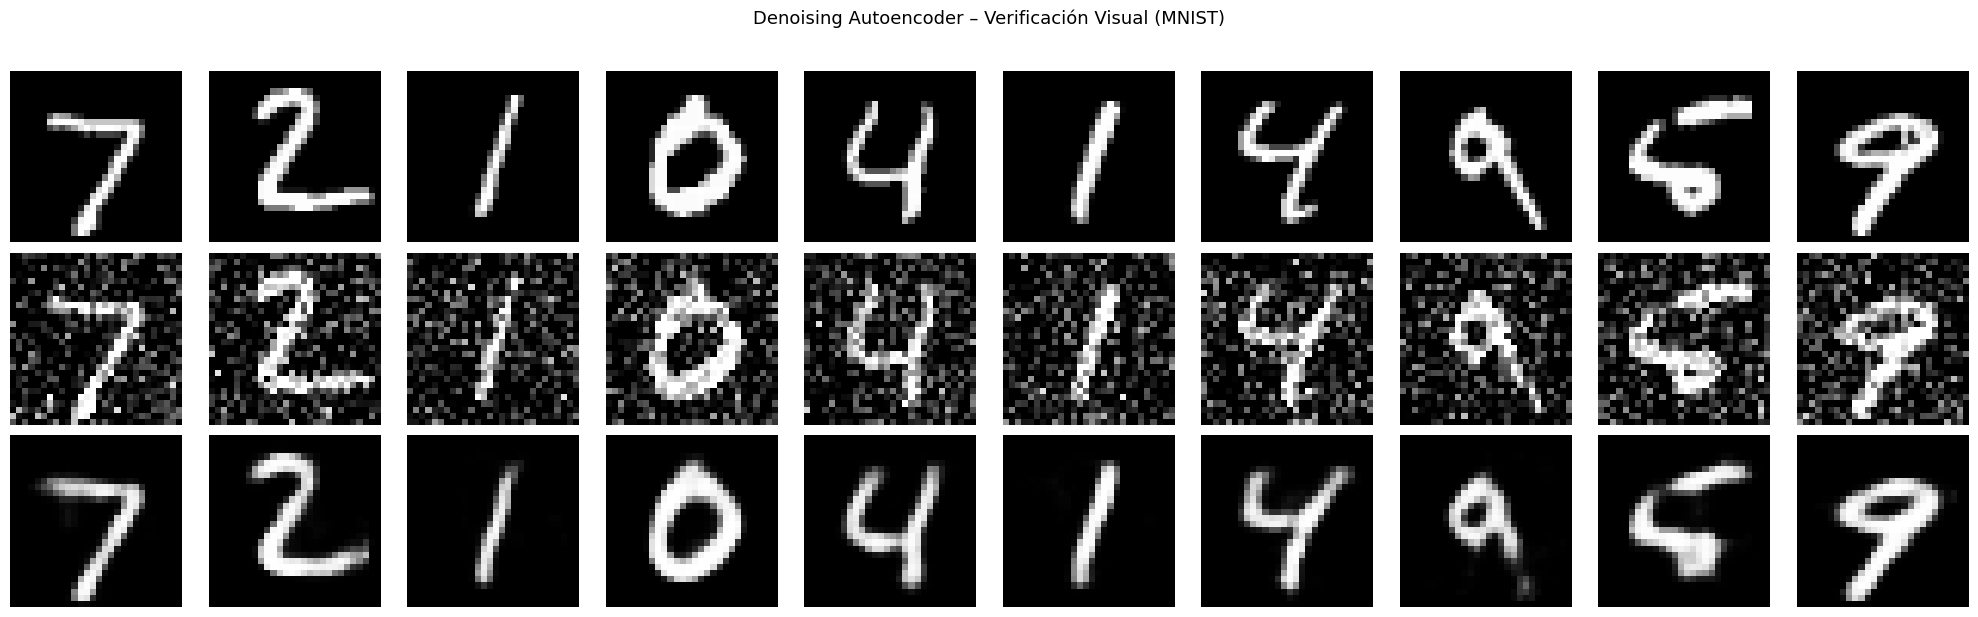

In [26]:
def visualize_denoising(model, x_clean, x_noisy, n=10):
    """
    Muestra 3 filas:
      - Fila 1: imágenes originales (limpias)
      - Fila 2: imágenes con ruido (entrada al autoencoder)
      - Fila 3: reconstrucción del autoencoder
    """
    # Reconstruir usando el autoencoder
    reconstructed = model.predict(x_noisy[:n])

    fig, axes = plt.subplots(3, n, figsize=(2*n, 6))
    row_labels = ['Original\n(limpia)', 'Con ruido\n(entrada)', 'Reconstruida\n(salida)']
    images     = [x_clean[:n], x_noisy[:n], reconstructed]

    for row in range(3):
        for col in range(n):
            axes[row, col].imshow(images[row][col].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(row_labels[row], fontsize=10, rotation=0,
                                labelpad=70, va='center')

    plt.suptitle('Denoising Autoencoder – Verificación Visual (MNIST)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


visualize_denoising(model, x_test_flat, x_test_noisy, n=10)

# Evaluación con distintos niveles de ruido

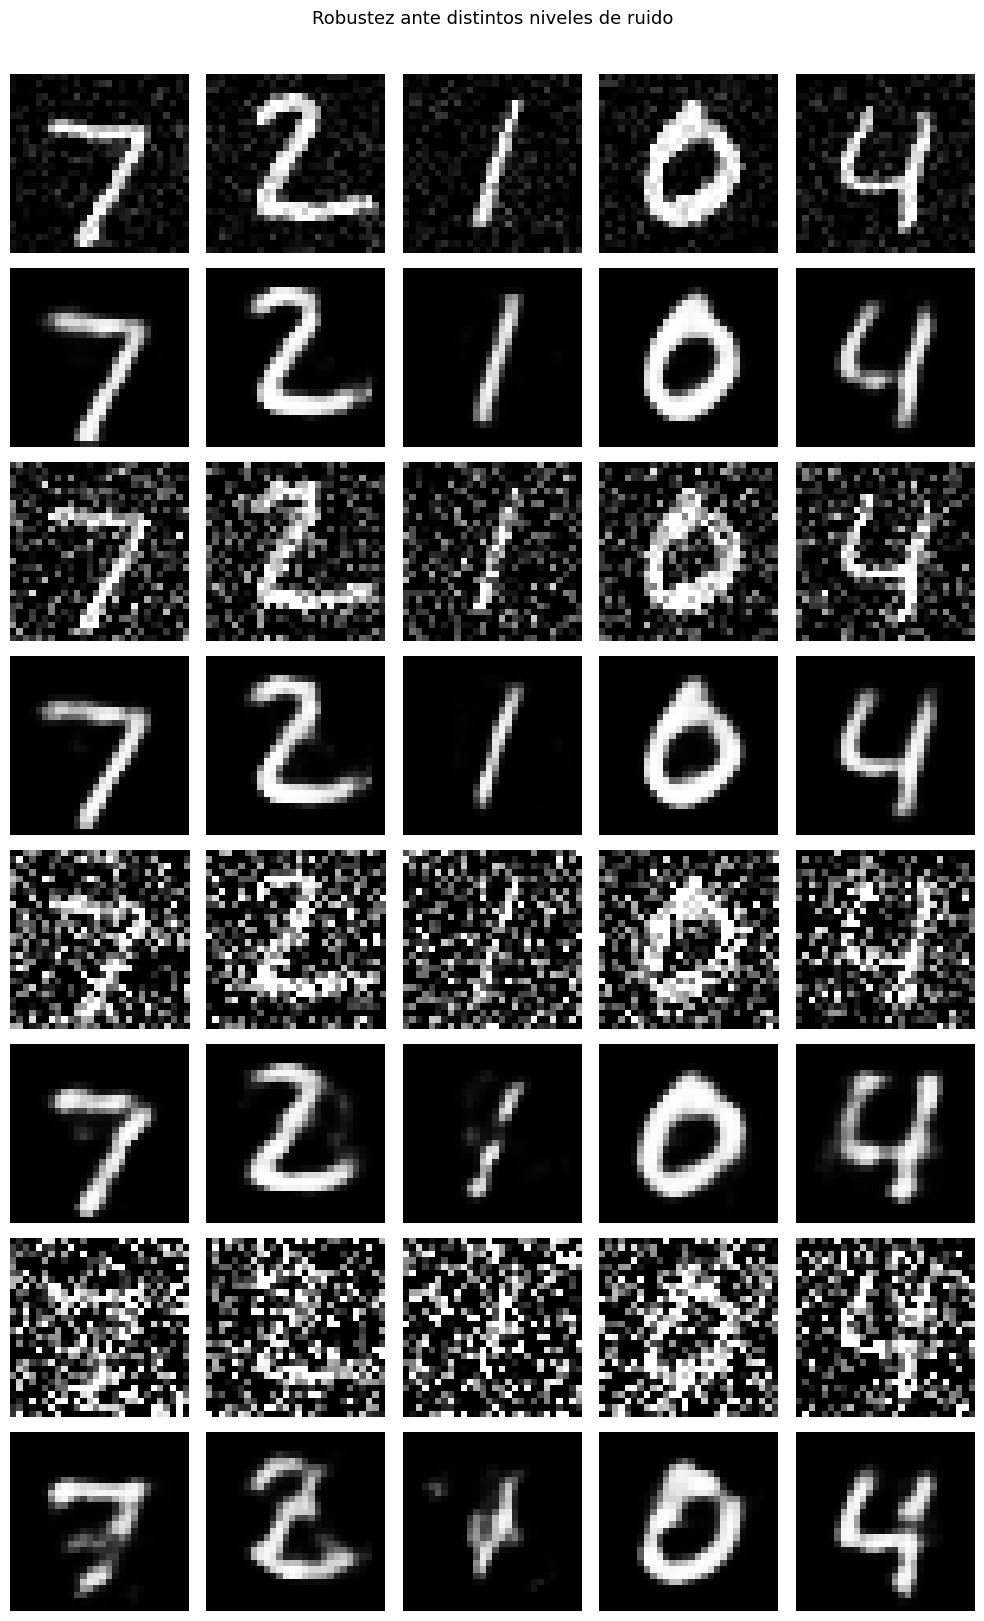

In [25]:
noise_levels = [0.1, 0.3, 0.5, 0.7]
n_imgs = 5

fig, axes = plt.subplots(len(noise_levels) * 2, n_imgs,
                         figsize=(2 * n_imgs, 4 * len(noise_levels)))

for idx, nf in enumerate(noise_levels):
    noisy = add_noise(x_test_flat[:n_imgs], nf)
    recon = model.predict(noisy, verbose=0)
    row_n = idx * 2
    row_r = idx * 2 + 1

    for col in range(n_imgs):
        axes[row_n, col].imshow(noisy[col].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[row_n, col].axis('off')
        axes[row_r, col].imshow(recon[col].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[row_r, col].axis('off')

    axes[row_n, 0].set_ylabel(f'noise={nf}\nEntrada', fontsize=9,
                               rotation=0, labelpad=75, va='center')
    axes[row_r, 0].set_ylabel(f'noise={nf}\nReconstruida', fontsize=9,
                               rotation=0, labelpad=75, va='center')

plt.suptitle('Robustez ante distintos niveles de ruido', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()